# Portfolio Tool — Walkthrough

This notebook drives the `portfolio` package end-to-end. Run cells top to bottom (**Shift+Enter**).

The flow:
1. Fetch real ETF prices via yfinance
2. Estimate covariance (Ledoit-Wolf shrinkage) and expected returns
3. Solve for the bucket-constrained min-variance and max-Sharpe portfolios
4. Plot the efficient frontier
5. Overlay Black-Litterman views
6. Backtest against a 60/40 benchmark

Edit the asset universe in `portfolio/assets.py` and the bucket policy in the same file.

In [1]:
# Make sure the package is importable when running from notebooks/
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# from pathlib import Path

# sys.path.insert(0, str(Path(__file__).resolve().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portfolio import (
    tickers, BUCKETS, ASSETS,
    fetch_prices, log_returns, annualize_returns,
    sample_cov, ledoit_wolf_cov, to_correlation,
    min_variance, max_sharpe, target_return,
    efficient_frontier, frontier_summary,
    View, black_litterman, implied_equilibrium_returns,
    backtest, make_min_variance_weight_fn, benchmark_60_40_weights,
    plot_frontier, plot_equity_curves, plot_weights_over_time,
)

print(f"Universe: {len(ASSETS)} assets across {len(BUCKETS)} buckets")
for a in ASSETS:
    print(f"  {a.ticker:5s}  {a.name:32s}  [{a.bucket}]")
print(f"\nPolicy: {BUCKETS}")

Universe: 10 assets across 3 buckets
  IEF    iShares 7-10Y Treasury            [Fixed Income]
  LQD    iShares IG Corporate              [Fixed Income]
  HYG    iShares High Yield Corporate      [Fixed Income]
  EMB    iShares EM Sovereign USD          [Fixed Income]
  SPY    SPDR S&P 500                      [Equities]
  IWM    iShares Russell 2000              [Equities]
  EFA    iShares MSCI EAFE                 [Equities]
  EEM    iShares MSCI Emerging Markets     [Equities]
  GLD    SPDR Gold Trust                   [Alternatives]
  VNQ    Vanguard Real Estate              [Alternatives]

Policy: {'Fixed Income': 0.5, 'Equities': 0.4, 'Alternatives': 0.1}


## 1. Fetch prices

This pulls adjusted-close daily prices from Yahoo Finance. First run takes ~10 seconds; subsequent runs hit the local cache (`cache/` folder).

In [2]:
prices = fetch_prices(tickers(), start="2018-01-01")
print(f"Shape: {prices.shape}")
print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail()

Shape: (2094, 10)
Range: 2018-01-02 to 2026-05-01


,IEF,LQD,HYG,EMB,SPY,IWM,EFA,EEM,GLD,VNQ
Date,,,,,,,,,,
2026-04-27,95.026810,108.863281,80.090324,95.619019,715.169983,277.140015,101.379997,63.639999,429.890015,94.779999
2026-04-28,94.937111,108.913086,79.980896,95.539360,711.690002,273.910004,100.959999,62.990002,421.910004,95.650002
2026-04-29,94.488594,108.305473,79.712303,95.091286,711.580017,272.079987,99.930000,62.689999,417.410004,94.900002
2026-04-30,94.667999,108.424995,79.960999,95.390007,718.659973,277.970001,102.320000,63.990002,423.660004,96.330002
2026-05-01,94.739998,108.599998,80.059998,95.570000,720.650024,279.279999,102.099998,64.129997,423.179993,96.059998


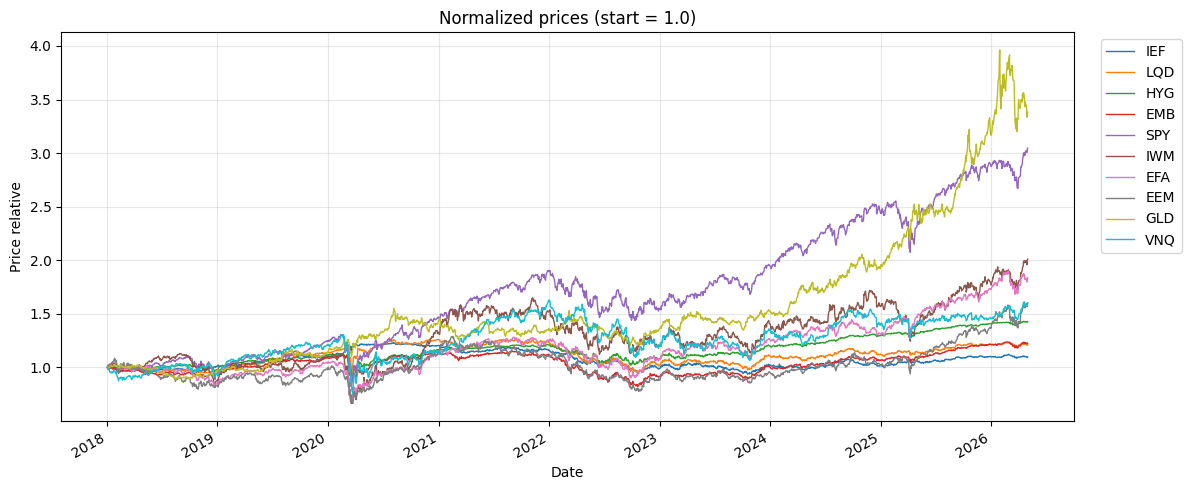

In [3]:
# Quick visual: normalized price chart
(prices / prices.iloc[0]).plot(figsize=(12, 5), linewidth=1)
plt.title("Normalized prices (start = 1.0)")
plt.ylabel("Price relative")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

## 2. Estimate returns and covariance

A few notes:
- We use **log returns** for estimation (they're closer to normally distributed) but report results in simple-return space.
- We use **Ledoit-Wolf shrinkage** for the covariance. With ~10 assets and ~5 years of daily data the sample covariance is reasonable, but shrinkage rarely hurts and often helps.
- **Historical mean returns are not good forecasts.** We'll compute them so you can see the pipeline, but the Black-Litterman section below shows a more principled alternative.

In [4]:
rets = log_returns(prices)
cov = ledoit_wolf_cov(rets)

# Convert mean log returns to annualized simple returns
mu = annualize_returns(rets)

# Display the volatilities and correlations for sanity
vols = pd.Series(np.sqrt(np.diag(cov.values)), index=cov.index, name="Annualized Vol")
print("Estimated annualized vols:")
print((vols * 100).round(1).to_string())
print(f"\nEstimated annualized returns (HISTORICAL — be skeptical):")
print((mu * 100).round(1).to_string())

Estimated annualized vols:
IEF     7.2
LQD     9.4
HYG     8.9
EMB    10.8
SPY    19.3
IWM    24.5
EFA    18.1
EEM    21.2
GLD    16.6
VNQ    22.1

Estimated annualized returns (HISTORICAL — be skeptical):
IEF     1.1
LQD     2.3
HYG     4.4
EMB     2.5
SPY    14.4
IWM     8.8
EFA     7.6
EEM     5.9
GLD    15.8
VNQ     5.8


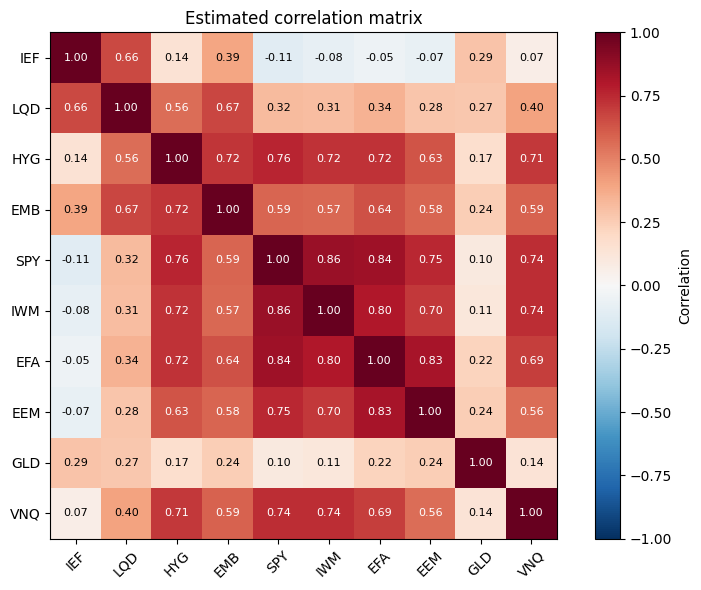

In [5]:
# Correlation heatmap
corr = to_correlation(cov)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.index, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.values[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, label="Correlation")
plt.title("Estimated correlation matrix")
plt.tight_layout()
plt.show()

## 3. Optimal portfolios under the bucket policy

The 50/40/10 split is a hard constraint. Inside each bucket the optimizer picks the mix.

**Min-variance** ignores expected returns. **Max-Sharpe** uses them.

In [6]:
mvp = min_variance(cov, mu)
print(mvp)
print()
print("Weights:")
for tk, w in mvp.weights.items():
    if w > 0.001:
        print(f"  {tk:5s}  {w:6.2%}")

OptResult(min_variance, status=optimal, E[R]=6.46%, vol=8.37%, Sharpe=0.771)

Weights:
  IEF    50.00%
  SPY    19.01%
  EFA    20.95%
  GLD    10.00%


In [7]:
msr = max_sharpe(cov, mu)
print(msr)
print()
print("Weights:")
for tk, w in msr.weights.items():
    if w > 0.001:
        print(f"  {tk:5s}  {w:6.2%}")

OptResult(max_sharpe, status=optimal, E[R]=7.88%, vol=8.66%, Sharpe=0.910)

Weights:
  IEF    50.00%
  SPY    40.00%
  GLD    10.00%


In [8]:
# Side-by-side comparison
summary = frontier_summary(cov, mu)
summary.style.format({"E[R]": "{:.2%}", "Vol": "{:.2%}", "Sharpe": "{:.3f}"})

,E[R],Vol,Sharpe
portfolio,,,
Min Variance,6.46%,8.37%,0.771
Max Sharpe,7.88%,8.66%,0.910
Equal Weight (1/N),6.85%,11.86%,0.577


## 4. Efficient frontier

The frontier shows the trade-off: at every level of risk, what's the highest expected return achievable under our bucket constraints? The upper bound is below `mu.max()` because the 50% Fixed Income mandate limits how much equity exposure we can take.

In [9]:
ef = efficient_frontier(cov, mu, n_points=30)
print(f"Frontier: {len(ef)} points")
print(f"  vol range:    {ef['vol'].min():.2%} to {ef['vol'].max():.2%}")
print(f"  return range: {ef['achieved_return'].min():.2%} to {ef['achieved_return'].max():.2%}")
ef[["target_return", "achieved_return", "vol", "sharpe"]].head()

Frontier: 30 points
  vol range:    8.37% to 11.81%
  return range: 6.46% to 9.51%


,target_return,achieved_return,vol,sharpe
0,0.064588,0.064616,0.083740,0.771625
1,0.065640,0.065640,0.083755,0.783713
2,0.066692,0.066692,0.083803,0.795820
3,0.067744,0.067744,0.083882,0.807610
4,0.068796,0.068796,0.083993,0.819067


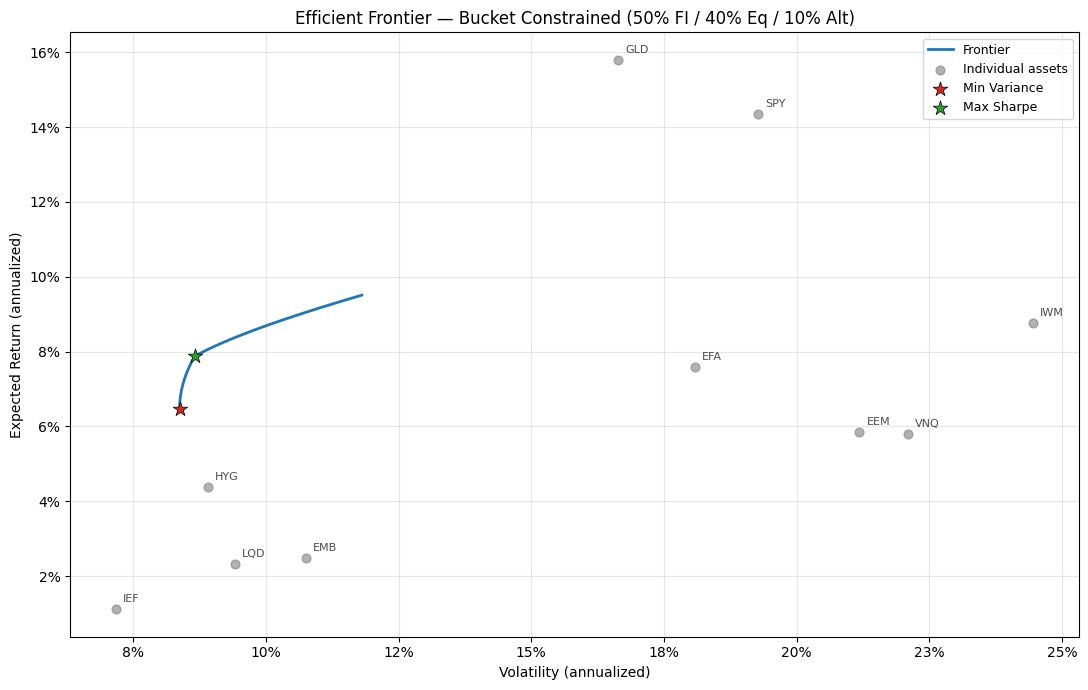

In [10]:
# Plot with min-variance and max-Sharpe highlighted
fig, ax = plt.subplots(figsize=(11, 7))
plot_frontier(
    ef, cov, mu,
    extra_points={
        "Min Variance": (mvp.volatility, mvp.expected_return),
        "Max Sharpe":   (msr.volatility, msr.expected_return),
    },
    title="Efficient Frontier — Bucket Constrained (50% FI / 40% Eq / 10% Alt)",
    ax=ax,
)
plt.tight_layout()
plt.show()

## 5. Black-Litterman views

Historical means are noisy. BL lets you express views in plain English ("I think US equities will outperform EM by 1.5%") and blends them with market-cap-implied equilibrium returns. The result is a more stable, less concentrated portfolio.

You define:
- **Market weights** — proxy for market-cap weights (here we use a rough sketch)
- **Views** — absolute or relative, with a confidence level in [0, 1]

In [11]:
# Approximate global market-cap proxy. Adjust to taste.
market_weights = pd.Series({
    "IEF": 0.20, "LQD": 0.10, "HYG": 0.05, "EMB": 0.05,
    "SPY": 0.30, "IWM": 0.05, "EFA": 0.15, "EEM": 0.05,
    "GLD": 0.025, "VNQ": 0.025,
})
assert abs(market_weights.sum() - 1.0) < 1e-6

# Show implied equilibrium returns
pi = implied_equilibrium_returns(cov, market_weights, risk_aversion=2.5)
pd.DataFrame({"Historical mu": mu, "Equilibrium pi": pi}).style.format("{:.2%}")

,Historical mu,Equilibrium pi
IEF,1.12%,0.27%
LQD,2.33%,1.48%
HYG,4.38%,2.21%
EMB,2.49%,2.40%
SPY,14.35%,5.38%
IWM,8.77%,6.34%
EFA,7.59%,4.90%
EEM,5.85%,5.12%
GLD,15.80%,1.23%
VNQ,5.79%,5.17%


In [12]:
# Two example views — edit freely
views = [
    # Absolute view: SPY will return 8% annually
    View(assets={"SPY": 1.0}, return_=0.08, confidence=0.5),

    # Relative view: EFA will outperform EEM by 2%
    View(assets={"EFA": 1.0, "EEM": -1.0}, return_=0.02, confidence=0.4),
]

mu_bl, cov_bl = black_litterman(cov, market_weights, views, risk_aversion=2.5, tau=0.05)

comparison = pd.DataFrame({
    "Equilibrium pi": pi,
    "Historical mu": mu,
    "BL Posterior":   mu_bl,
})
comparison.style.format("{:.2%}")

,Equilibrium pi,Historical mu,BL Posterior
IEF,0.27%,1.12%,0.26%
LQD,1.48%,2.33%,1.63%
HYG,2.21%,4.38%,2.52%
EMB,2.40%,2.49%,2.65%
SPY,5.38%,14.35%,6.22%
IWM,6.34%,8.77%,7.26%
EFA,4.90%,7.59%,5.65%
EEM,5.12%,5.85%,5.26%
GLD,1.23%,15.80%,1.22%
VNQ,5.17%,5.79%,5.98%


In [13]:
# Optimize using BL inputs
mvp_bl = min_variance(cov_bl, mu_bl)
msr_bl = max_sharpe(cov_bl, mu_bl)

print("Black-Litterman based portfolios:")
print(mvp_bl)
print(msr_bl)

# Compare weights of historical-vs-BL max-Sharpe
weights_compare = pd.DataFrame({
    "Max-Sharpe (historical)": msr.weights,
    "Max-Sharpe (BL)":         msr_bl.weights,
})
weights_compare.style.format("{:.2%}").background_gradient(axis=None, cmap="Blues")

Black-Litterman based portfolios:
OptResult(min_variance, status=optimal, E[R]=2.62%, vol=8.54%, Sharpe=0.307)
OptResult(max_sharpe, status=optimal, E[R]=3.69%, vol=11.15%, Sharpe=0.331)


,Max-Sharpe (historical),Max-Sharpe (BL)
IEF,50.00%,18.50%
LQD,0.00%,4.92%
HYG,0.00%,21.50%
EMB,0.00%,5.07%
SPY,40.00%,25.23%
IWM,0.00%,1.56%
EFA,0.00%,13.21%
EEM,0.00%,0.00%
GLD,10.00%,3.00%
VNQ,0.00%,7.00%


## 6. Backtest

Walk-forward: at each rebalance date (default month-end), use the trailing 2 years of data to estimate covariance, solve for the min-variance portfolio under bucket constraints, and rebalance. Charge transaction costs on turnover.

This is research-grade, not production. It does NOT model bid-ask spreads, taxes, or borrow costs.

In [14]:
# Min-variance with bucket constraints, monthly rebalance
weight_fn = make_min_variance_weight_fn(use_shrinkage=True)
bt_mvp = backtest(
    prices,
    weight_fn,
    rebalance_freq="ME",       # month-end
    lookback_days=504,         # ~2 years
    transaction_cost_bps=10,   # 10bps per dollar traded
)

# 60/40 SPY/IEF benchmark
def bench_fn(window):
    return benchmark_60_40_weights(window)

bt_bench = backtest(prices, bench_fn, rebalance_freq="ME", lookback_days=504, transaction_cost_bps=10)

print("Bucket-constrained min-variance:")
for k, v in bt_mvp.summary.items():
    print(f"  {k}: {v:.2%}" if k != "Sharpe" else f"  {k}: {v:.3f}")
print("\n60/40 benchmark:")
for k, v in bt_bench.summary.items():
    print(f"  {k}: {v:.2%}" if k != "Sharpe" else f"  {k}: {v:.3f}")

Bucket-constrained min-variance:
  CAGR: 4.89%
  Vol: 8.01%
  Sharpe: 0.637
  MaxDD: -20.49%

60/40 benchmark:
  CAGR: 6.99%
  Vol: 10.81%
  Sharpe: 0.679
  MaxDD: -21.02%


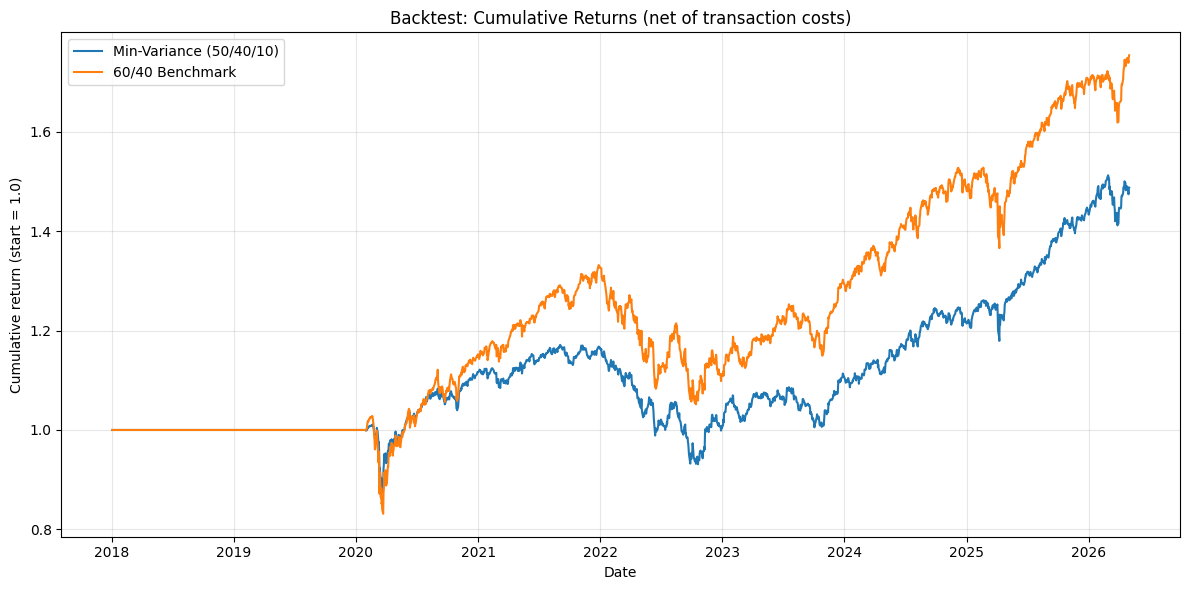

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_equity_curves(
    {"Min-Variance (50/40/10)": bt_mvp.equity, "60/40 Benchmark": bt_bench.equity},
    title="Backtest: Cumulative Returns (net of transaction costs)",
    ax=ax,
)
plt.tight_layout()
plt.show()

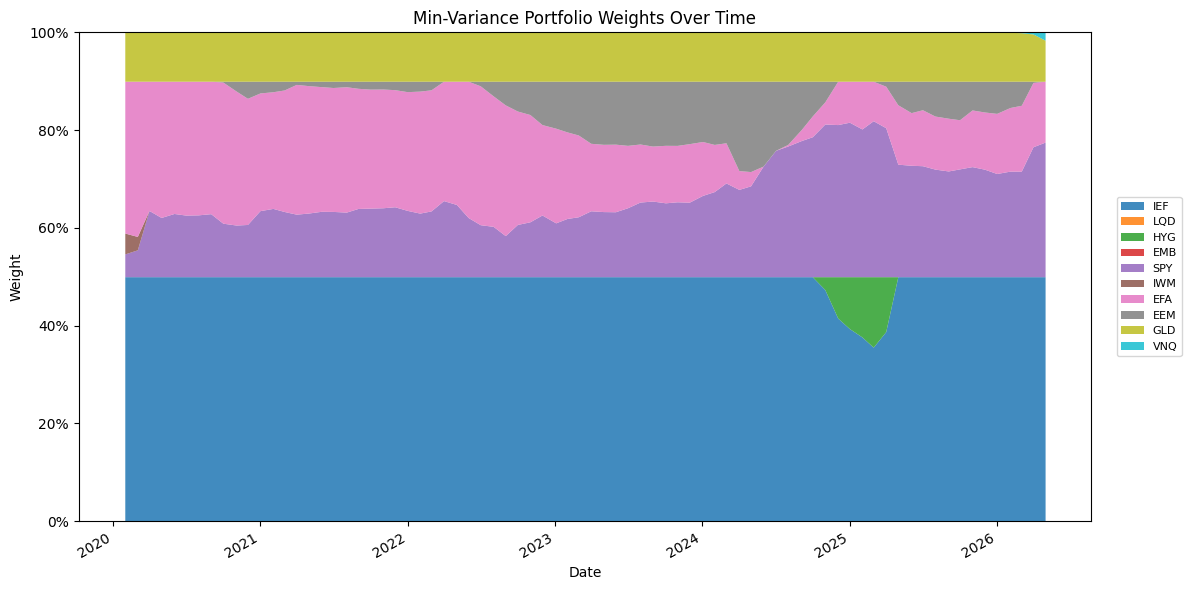

In [16]:
# Weights drift over time
fig, ax = plt.subplots(figsize=(12, 6))
plot_weights_over_time(bt_mvp.weights, title="Min-Variance Portfolio Weights Over Time", ax=ax)
plt.tight_layout()
plt.show()

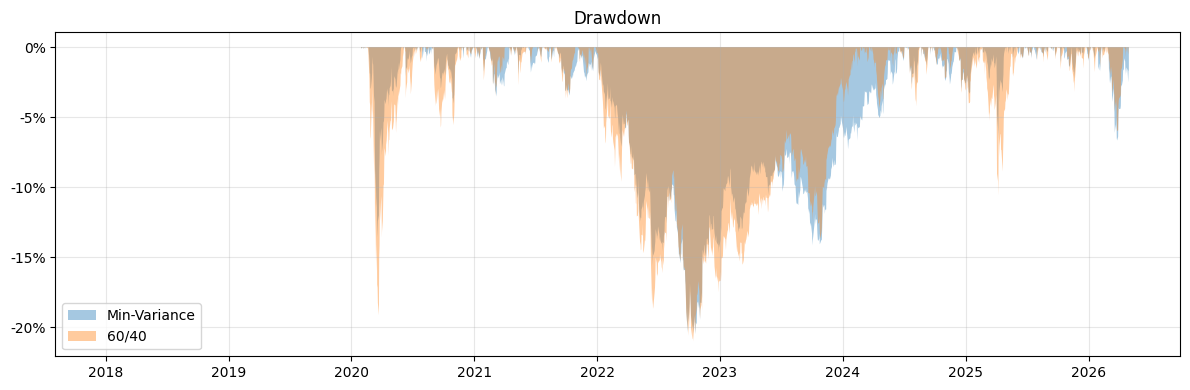

In [17]:
# Rolling drawdown
def rolling_dd(equity):
    return equity / equity.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(bt_mvp.equity.index, rolling_dd(bt_mvp.equity), 0, alpha=0.4, label="Min-Variance")
ax.fill_between(bt_bench.equity.index, rolling_dd(bt_bench.equity), 0, alpha=0.4, label="60/40")
ax.set_title("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Where to take this next

- **Replace the asset universe** in `portfolio/assets.py` to match what you actually want to invest in (UCITS ETFs for Europe, individual stocks, factor ETFs, etc.).
- **Tune your views** in the Black-Litterman section. This is where your judgment as an investor enters the model.
- **Try different rebalancing frequencies** (`QE` quarterly, `YE` annually) and lookback windows. Less frequent rebalancing = less turnover = lower costs.
- **Add a target-volatility constraint** by adding a `cp.quad_form(w, Sigma) <= target_var` constraint in `optimize.py`.
- **Replace yfinance with a paid data source** (Bloomberg, Refinitiv, Tiingo) by editing `data.py`. The rest of the pipeline doesn't care where prices come from.
- **Build a Streamlit or Dash UI** on top of this package — the optimizers return clean Series/DataFrames, so it's straightforward to wire to a web frontend.

A serious caveat to take with you: optimization on noisy estimates produces noisy portfolios. Sample-covariance min-variance often does worse out-of-sample than naive 1/N. The reason this tool's bucket-constrained min-variance does OK is that the constraints regularize the problem heavily — they're doing most of the work, not the optimizer. That's a feature, not a bug.